# **Hyperparameter Tuning**

**Why Evaluation is Important in AI**

- Building a model is not enough  
- We must measure how good it is  

**Evaluation helps us:**

- Compare models  
- Detect overfitting  
- Improve performance  
- Build trust in AI systems  



- Without evaluation → AI is just guessing  
- With evaluation → AI becomes measurable & reliable

# ✅ Part 1: Cross Validation, Bias-Variance & Learning Curves


## 1️⃣ Cross Validation (CV)

### 🔹 Why Not Just One Train-Test Split?

- A single split can be misleading  
- Performance may depend on how data was split  
- We need more reliable evaluation  

👉 **Solution → Cross Validation**


### 🔹 K-Fold Cross Validation

- Dataset is divided into **K equal parts**  
- Model trains on **K-1 folds**  
- Tests on the remaining fold  
- Process repeats **K times**  
- Final score = average of all runs  

**Example:**
- K = 5  
- Model trains 5 times  
- Each fold becomes test once  


### 🔹 Benefits

- More reliable performance estimate  
- Uses full dataset efficiently  
- Reduces variance from random splits  


## 2️⃣ Bias-Variance Tradeoff

### 🔹 Bias

- Error due to overly simple model  
- High bias → Underfitting  

**Example:**
- Linear model for highly nonlinear data  


### 🔹 Variance

- Error due to model being too complex  
- High variance → Overfitting  

**Example:**
- Deep tree memorizing training data  


### 🎯 The Goal

We want:

- Low bias  
- Low variance  
- Good generalization  

This balance is called:

⭐ **Bias-Variance Tradeoff**


## 3️⃣ Learning Curves

### 🔹 What Are Learning Curves?

Graphs that show:

- Training score vs dataset size  
- Validation score vs dataset size  

They help detect:

- Overfitting  
- Underfitting  
- Whether more data will help  


### 🔹 Interpretation

#### 🔸 Overfitting

- Training score = High  
- Validation score = Low  
- Big gap between curves  

#### 🔸 Underfitting

- Both scores = Low  
- Curves are close together  

#### 🔸 Good Fit

- Both scores = High  
- Small gap  


## 4️⃣ Practical Coding – K-Fold Cross Validation

Import Libraries

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

Load dataset

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

Cross Validation Scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Average CV Score: 0.9507995652848935


Define model

In [ ]:
model = LogisticRegression(max_iter=5000)

Perform 5-Fold Cross Validation

In [ ]:
scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Scores:", scores)
print("Average CV Score:", np.mean(scores))

## 5️⃣ Practical Coding – Bias vs Variance Example

We will compare:
- Simple model (high bias)
- Complex model (high variance)

Import Libraries

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


Train-test split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Simple model (high bias)

In [ ]:
simple_model = DecisionTreeClassifier(max_depth=1)
simple_model.fit(X_train, y_train)

Complex model (high variance)

In [ ]:
complex_model = DecisionTreeClassifier(max_depth=None)
complex_model.fit(X_train, y_train)

Predictions

In [ ]:
simple_train_acc = accuracy_score(y_train, simple_model.predict(X_train))
simple_test_acc = accuracy_score(y_test, simple_model.predict(X_test))

complex_train_acc = accuracy_score(y_train, complex_model.predict(X_train))
complex_test_acc = accuracy_score(y_test, complex_model.predict(X_test))

print("Simple Model Train Accuracy:", simple_train_acc)
print("Simple Model Test Accuracy:", simple_test_acc)

print("\nComplex Model Train Accuracy:", complex_train_acc)
print("Complex Model Test Accuracy:", complex_test_acc)


Simple Model Train Accuracy: 0.9208791208791208
Simple Model Test Accuracy: 0.8947368421052632

Complex Model Train Accuracy: 1.0
Complex Model Test Accuracy: 0.9473684210526315


## 6️⃣ Practical Coding – Learning Curves

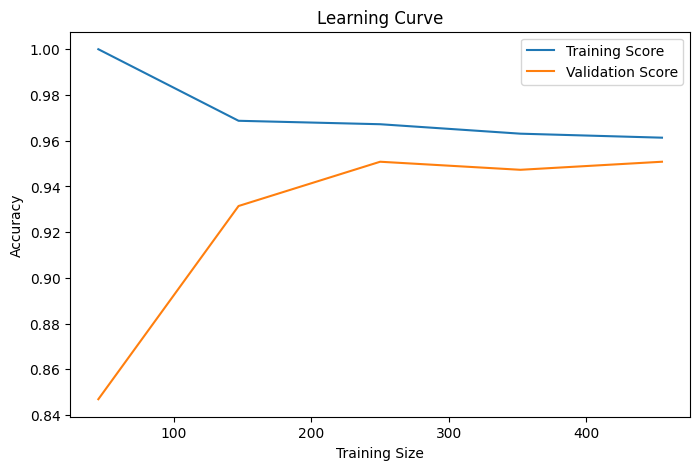

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

model = LogisticRegression(max_iter=5000)

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


# ✅ Part 2: Hyperparameter Tuning (Core Optimization)


## 1️⃣ What Are Hyperparameters?

### 🔹 Parameters vs Hyperparameters


### 🔸 Parameters

- Learned automatically from data  

**Examples:**
- Weights in Linear Regression  
- Coefficients in Logistic Regression  


### 🔸 Hyperparameters

- Set manually before training  
- Control model behavior  

**Examples:**
- Learning rate  
- max_depth (Decision Tree)  
- C (Logistic Regression)  
- n_estimators (Random Forest)  


👉 Hyperparameters affect:

- Model complexity  
- Overfitting / Underfitting  
- Training time  


## 2️⃣ Why Hyperparameter Tuning Matters

### Without tuning:

- Model may underperform  
- Model may overfit  
- Model may be unstable  

### With tuning:

- Better generalization  
- Higher accuracy  
- More reliable model  


## 3️⃣ Grid Search

### 🔹 What is Grid Search?

- Try all combinations of hyperparameters  
- Evaluate each using cross-validation  
- Select best performing combination  


### Example:

If:

- C = [0.1, 1, 10]  
- solver = ["liblinear", "lbfgs"]  

Total combinations = 3 × 2 = 6 models  


### 🔹 Advantages

- Simple  
- Exhaustive search  
- Finds best within given grid  

### 🔹 Disadvantages

- Computationally expensive  
- Slow for large search spaces  


## 4️⃣ Random Search

### 🔹 What is Random Search?

- Randomly samples hyperparameter combinations  
- Faster than Grid Search  
- Often finds good solutions quickly  


### 🔹 Why Random Search Can Be Better

Research shows:

- Not all hyperparameters are equally important  
- Random search explores more diverse regions  


## 5️⃣ Practical Coding – Grid Search

Import Libraries

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split

Load dataset

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Define model

In [ ]:
model = LogisticRegression(max_iter=5000)

 Define hyperparameter grid

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

Grid Search with 5-fold CV

In [ ]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

Train

In [ ]:
grid_search.fit(X_train, y_train)

Best parameters

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Test performance

In [ ]:
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)

print("Test Accuracy:", test_accuracy)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV Score: 0.9626373626373628
Test Accuracy: 0.956140350877193


## 6️⃣ Practical Coding – Random Search

Import Libraries

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

Define parameter distribution


In [ ]:
param_dist = {
    'C': uniform(0.01, 10),
    'solver': ['liblinear', 'lbfgs']
}

Random Search

In [ ]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,      # Number of random combinations
    cv=5,
    scoring='accuracy',
    random_state=42
)

Train

In [ ]:
random_search.fit(X_train, y_train)

Best parameters

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Test performance

In [ ]:
best_random_model = random_search.best_estimator_
test_accuracy = best_random_model.score(X_test, y_test)

print("Test Accuracy:", test_accuracy)


## 7️⃣ Practical Comparison – Before vs After Tuning

Baseline model (no tuning)


In [ ]:
baseline_model = LogisticRegression(max_iter=5000)
baseline_model.fit(X_train, y_train)

baseline_accuracy = baseline_model.score(X_test, y_test)

print("Baseline Accuracy:", baseline_accuracy)
print("Tuned (GridSearch) Accuracy:", test_accuracy)


Baseline Accuracy: 0.956140350877193
Tuned (GridSearch) Accuracy: 0.956140350877193


# ✅ Part 3: Hyperparameter Tuning (Deep Understanding + Practical Optimization)


## 1️⃣ Understanding Hyperparameters Deeply


### 🔹 What Exactly Are Hyperparameters?

- Values set before training starts  
- Control:

  - Learning behavior  
  - Model complexity  
  - Regularization strength  
  - Training speed  


### 🔹 Examples in Different Models


#### 🔸 Logistic Regression

- `C` → Inverse of regularization strength  
- `penalty` → L1 or L2  
- `solver` → Optimization algorithm  


#### 🔸 Decision Tree

- `max_depth`  
- `min_samples_split`  
- `min_samples_leaf`  


#### 🔸 Random Forest

- `n_estimators`  
- `max_depth`  
- `max_features`  


## 2️⃣ The Correct Tuning Workflow (Very Important)

### 🔹 Proper Pipeline

1. Split data → Train / Test  
2. Perform tuning only on training set  
3. Use Cross Validation inside tuning  
4. Select best model  
5. Evaluate once on test set  

🚫 Never tune on test data  


## 3️⃣ Grid Search – Detailed Practical Example


Import Libraries

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

Load dataset

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

Train-test split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Define model

In [ ]:

model = DecisionTreeClassifier(random_state=42)

Define hyperparameter grid

In [ ]:

param_grid = {
    'max_depth': [None, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

Grid Search

In [ ]:

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

Train

In [ ]:
#
grid_search.fit(X_train, y_train)

Results


In [ ]:
#
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Test Evaluation

In [ ]:
#
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross Validation Score: 0.9384615384615385
Test Accuracy: 0.9385964912280702


## 4️⃣ Random Search – Faster Optimization

### 🔹 When to Use Random Search?

- Large parameter space  
- Limited computational resources  
- Want faster exploration  


Import Libraries

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

Parameter distribution

In [ ]:
param_dist = {
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

Random Search

In [ ]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

Train

In [ ]:
random_search.fit(X_train, y_train)

Results

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

Test Evaluation

In [ ]:
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_random))


Best Parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 8}
Best Cross Validation Score: 0.9340659340659341
Test Accuracy: 0.9473684210526315


## 5️⃣ Comparing Baseline vs Tuned Model

Baseline model

In [ ]:
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_accuracy = accuracy_score(y_test, baseline_model.predict(X_test))

print("Baseline Accuracy:", baseline_accuracy)
print("Tuned (GridSearch) Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned (RandomSearch) Accuracy:", accuracy_score(y_test, y_pred_random))


Baseline Accuracy: 0.9473684210526315
Tuned (GridSearch) Accuracy: 0.9385964912280702
Tuned (RandomSearch) Accuracy: 0.9473684210526315


## 6️⃣ How to Choose Search Strategy (Teaching Insight)

### 🔹 Small Dataset + Few Parameters

- Use Grid Search  

### 🔹 Large Dataset + Many Parameters

- Use Random Search  

### 🔹 Very Large Models (Deep Learning)

Use:

- Random Search  
- Bayesian Optimization  
- Hyperband  


## 7️⃣ Common Student Mistakes (Important)

❌ Tuning on test data  
❌ Not using cross-validation  
❌ Searching too large parameter space blindly  
❌ Not comparing against baseline  


# ✅ Part 4: Regularization, Early Stopping & Real-World Optimization Workflow


## 1️⃣ Regularization (Controlling Overfitting)

### 🔹 What is Regularization?

- Technique to prevent overfitting  
- Adds penalty for large model weights  
- Encourages simpler models  


### 🔹 Types of Regularization

#### 🔸 L1 Regularization (Lasso)

- Adds absolute value penalty  
- Can shrink some weights to zero  
- Performs feature selection  

#### 🔸 L2 Regularization (Ridge)

- Adds squared penalty  
- Shrinks weights smoothly  
- More stable  


### 🔹 Regularization in Logistic Regression

- Controlled by parameter `C`  
- Smaller `C` → Stronger regularization  
- Larger `C` → Weaker regularization  


## 2️⃣ Practical Coding – L1 vs L2 Regularization


Import Libraries

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Load dataset

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

L2 Regularization

In [ ]:
#
l2_model = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')
l2_model.fit(X_train, y_train)
l2_accuracy = accuracy_score(y_test, l2_model.predict(X_test))
print("L2 Regularization Accuracy:", l2_accuracy)

L1 Regularization

In [ ]:
#
l1_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear')
l1_model.fit(X_train, y_train)
l1_accuracy = accuracy_score(y_test, l1_model.predict(X_test))
print("L1 Regularization Accuracy:", l1_accuracy)


L2 Regularization Accuracy: 0.956140350877193
L1 Regularization Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 3️⃣ Early Stopping

### 🔹 What is Early Stopping?

- Stop training when validation performance stops improving  
- Prevents overfitting  
- Saves computation time  


### 🔹 How It Works

1. Train model in iterations  
2. Monitor validation score  
3. Stop if performance stops improving for several rounds  


## 4️⃣ Practical Coding – Early Stopping (Gradient Boosting)


Import Libraries

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

 Split again with validation set

In [ ]:
#
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

Model with early stopping

In [ ]:
#
gb_model = GradientBoostingClassifier(
    n_estimators=500,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=42
)

gb_model.fit(X_train_full, y_train_full)

print("Test Accuracy:", accuracy_score(y_test, gb_model.predict(X_test)))


Test Accuracy: 0.9473684210526315


## 5️⃣ Practical Optimization Checklist (Real-World Workflow)

### ✅ Step 1: Baseline Model

- Train simple model  
- Measure metrics  

### ✅ Step 2: Diagnose

- Check train vs test gap  
- Look for overfitting/underfitting  

### ✅ Step 3: Improve

- Add regularization  
- Tune hyperparameters  
- Try different algorithms  

### ✅ Step 4: Validate

- Use cross-validation  
- Compare models fairly  

### ✅ Step 5: Final Evaluation

- Evaluate once on test set  
- Report multiple metrics  


## 6️⃣ Full Mini Optimization Example


Import Libraries

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

Baseline

In [ ]:
baseline = RandomForestClassifier(random_state=42)
baseline.fit(X_train_full, y_train_full)

baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print("Baseline Accuracy:", baseline_acc)

Hyperparameter tuning

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_full, y_train_full)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
tuned_acc = accuracy_score(y_test, best_model.predict(X_test))

print("Tuned Accuracy:", tuned_acc)


Baseline Accuracy: 0.9649122807017544
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Accuracy: 0.9649122807017544


## 7️⃣ Final Message

Optimization is NOT:

- Random guessing  
- Blindly increasing model complexity  
- Only chasing accuracy  

Optimization IS:

- Structured experimentation  
- Careful validation  
- Controlling bias & variance  
- Building trustworthy AI systems  
